[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ELTE-DSED/Intro-Data-Security/blob/main/module_07_synthetic_data_generation/Lab_7a_Tabular_Synthetic_Data_Generation.ipynb)

# **Lab 7a: Tabular Synthetic Data Generation**

**Course:** Introduction to Data Security Pr.  
**Module 7:**  Synthetic Data Generation  
**Estimated Time:** 90 minutes

---

By the end of this lab, you will understand:

1. **Synthetic Data:** Generating realistic but artificial data from distributions
2. **Privacy Benefits:** Synthetic data as privacy-preserving alternative to real data
3. **Generation Methods:** VAE, GAN, and diffusion-based approaches
4. **Utility Metrics:** Assessing synthetic data quality and realism
5. **Privacy Guarantees:** Formal differential privacy for synthetic data
6. **Real-World Applications:** Healthcare, finance, and tabular ML datasets

## Table of Contents

1. [Threat Model & Use Cases](#threat-model)
2. [VAE-Based Generation](#vae)
3. [GAN-Based Generation](#gan)
4. [Utility Evaluation](#utility)
5. [Privacy Analysis](#privacy)
6. [Exercises](#exercises)

## Threat Model & Use Cases <a id="threat-model"></a>

**Core Problem:** Share ML datasets publicly without revealing sensitive information

| Domain | Real Data Risk | Synthetic Solution | Benefit |
|--------|----------------|--------------------|--------|
| **Healthcare** | Patient records, diagnoses | Synthetic patients with same disease distribution | HIPAA compliance |
| **Finance** | Transaction history, credit scores | Synthetic users with same spending patterns | PCI compliance |
| **Census** | Demographic information | Synthetic population with same statistics | GDPR compliance |

### Key Advantages:

- **Perfect Privacy:** No real individuals identifiable from synthetic data
- **Shareable:** Can publish synthetic data openly for research
- **Compliance:** Satisfies privacy regulations (GDPR, HIPAA, CCPA)
- **Utility:** Preserves statistical properties for ML model training

## Synthetic Data Generation Methods <a id="theory"></a>

### Method 1: Variational Autoencoder (VAE)

**Architecture:** Encoder → Latent Space → Decoder

- Learns continuous latent representation of data
- Sample from latent space → Generate new samples
- **Advantage:** Smooth generation, theoretical justification
- **Disadvantage:** Mode collapse, less sharp features

### Method 2: Generative Adversarial Network (GAN)

**Architecture:** Generator (fake data) vs Discriminator (real/fake classifier)

- Generator learns to fool discriminator
- **Advantage:** Sharp, realistic generation
- **Disadvantage:** Training instability, mode collapse

### Method 3: Diffusion Models (Noise-Based)

**Architecture:** Iteratively add noise → Learn reverse process

- Denoise corrupted data back to real distribution
- **Advantage:** Stable training, high quality
- **Disadvantage:** Slower generation (many denoising steps)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import ks_2samp, entropy
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [2]:
# Load real tabular data (Iris dataset)
iris = load_iris()
X_real = iris.data
y_real = iris.target

# Standardize
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

# Create PyTorch dataset including labels
X_tensor = torch.FloatTensor(X_real_scaled)
y_tensor = torch.LongTensor(y_real)
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Real data shape: {X_real_scaled.shape}")
print(f"Features: {iris.feature_names}")

Real data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## PART 1: VAE-Based Synthetic Data Generation

In [3]:
class CVAE(nn.Module):
    def __init__(self, input_dim=4, latent_dim=2, n_classes=3):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_emb = nn.Embedding(n_classes, n_classes)
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + n_classes, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(8, latent_dim)
        self.fc_logvar = nn.Linear(8, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_classes, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    
    def encode(self, x, labels):
        c = self.label_emb(labels)
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, labels):
        c = self.label_emb(labels)
        return self.decoder(torch.cat([z, c], dim=1))
    
    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, labels), mu, logvar, z
    
    def generate(self, n_samples, labels):
        with torch.no_grad():
            z = torch.randn(n_samples, self.latent_dim).to(device)
            samples = self.decode(z, labels).cpu().numpy()
        return samples

In [4]:
def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + kld) / x.size(0)

In [5]:
def train_vae(model, train_loader, epochs=200):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            recon, mu, logvar, _ = model(x, y)
            loss = vae_loss(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))
        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1}/{epochs}: Loss = {losses[-1]:.4f}')
    return model, losses

In [ ]:
print('\nTraining VAE...')
vae = CVAE(input_dim=4, latent_dim=2).to(device)
vae, vae_losses = train_vae(vae, train_loader, epochs=100)

print('\nGenerating synthetic data...')
synth_labels = torch.LongTensor(y_real).to(device)
X_synthetic_vae = vae.generate(n_samples=150, labels=synth_labels)
X_synthetic_vae = scaler.inverse_transform(X_synthetic_vae)
y_synthetic_vae = y_real.copy()

print(f'Generated {len(X_synthetic_vae)} synthetic samples')
print(f'Real data range: [{X_real.min():.2f}, {X_real.max():.2f}]')
print(f'Synthetic data range: [{X_synthetic_vae.min():.2f}, {X_synthetic_vae.max():.2f}]')


Training CVAE...
Epoch 20/100: Loss = 3.2215
Epoch 40/100: Loss = 1.7434
Epoch 60/100: Loss = 1.2294
Epoch 80/100: Loss = 1.1109
Epoch 100/100: Loss = 1.0870

Generating synthetic data...
Generated 150 synthetic samples
Real data range: [0.10, 7.90]
Synthetic data range: [0.16, 6.66]


### Visualizing VAE Synthetic Data vs. Real Data

Let's compare the distribution of the real data and the synthetic data generated by the VAE using a 2D scatter plot (first two features).

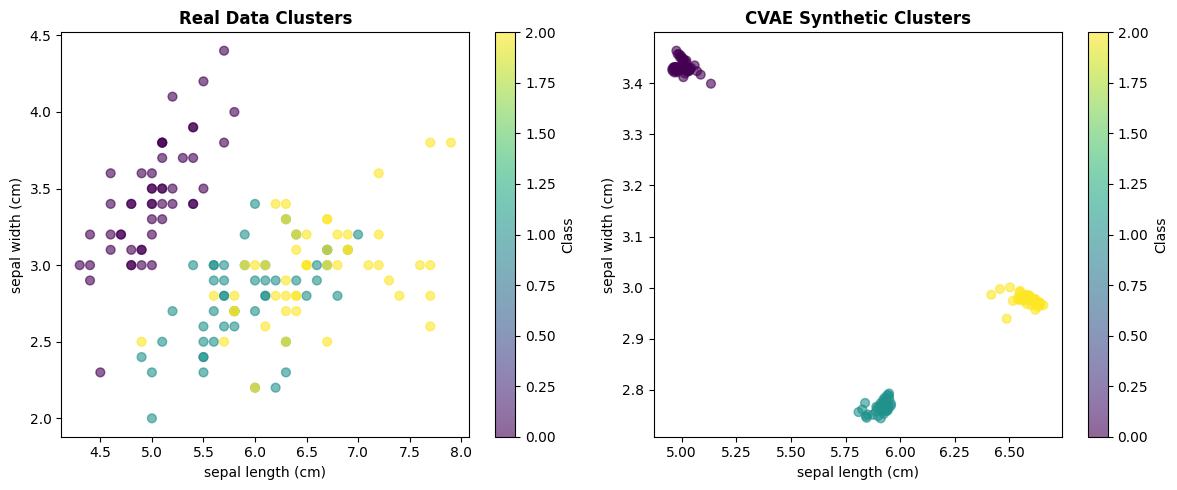

In [7]:
plt.figure(figsize=(12, 5))

# Real data scatter
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_real[:, 0], X_real[:, 1], c=y_real, cmap='viridis', alpha=0.6, s=40, label='Real Data')
plt.title('Real Data Clusters', fontsize=12, fontweight='bold')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.colorbar(scatter, label='Class')

# VAE data scatter
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_synthetic_vae[:, 0], X_synthetic_vae[:, 1], c=y_synthetic_vae, cmap='viridis', alpha=0.6, s=40, label='VAE Synthetic')
plt.title('CVAE Synthetic Clusters', fontsize=12, fontweight='bold')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.colorbar(scatter2, label='Class')

plt.tight_layout()
plt.show()

## PART 2: GAN-Based Synthetic Data Generation

In [8]:
class Generator(nn.Module):
    def __init__(self, latent_dim=10, output_dim=4, n_classes=3):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + n_classes, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, output_dim)
        )
    def forward(self, z, labels):
        c = self.label_emb(labels)
        return self.model(torch.cat([z, c], dim=1))

In [9]:
class Discriminator(nn.Module):
    def __init__(self, input_dim=4, n_classes=3):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        self.model = nn.Sequential(
            nn.Linear(input_dim + n_classes, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    def forward(self, x, labels):
        c = self.label_emb(labels)
        return self.model(torch.cat([x, c], dim=1))

In [10]:
def train_gan(generator, discriminator, train_loader, epochs=500):
    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()
    latent_dim = 10
    
    for epoch in range(epochs):
        for x, y in train_loader:
            batch_size = x.size(0)
            x, y = x.to(device), y.to(device)
            
            # Train Discriminator
            d_optimizer.zero_grad()
            real_label = torch.ones(batch_size, 1).to(device) * 0.9 # logic smoothing
            fake_label = torch.zeros(batch_size, 1).to(device)
            
            output = discriminator(x, y)
            d_loss_real = criterion(output, real_label)
            
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_data = generator(z, y)
            output = discriminator(fake_data.detach(), y)
            d_loss_fake = criterion(output, fake_label)
            
            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optimizer.step()
            
            # Train Generator
            g_optimizer.zero_grad()
            output = discriminator(fake_data, y)
            g_loss = criterion(output, torch.ones(batch_size, 1).to(device))
            g_loss.backward()
            g_optimizer.step()
            
        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1}/{epochs}: D_Loss={d_loss.item():.4f}, G_Loss={g_loss.item():.4f}')
    return generator

In [11]:
print('\nTraining CGAN...')
generator = Generator(n_classes=3).to(device)
discriminator = Discriminator(n_classes=3).to(device)
generator = train_gan(generator, discriminator, train_loader, epochs=1000)

print('\nGenerating synthetic data...')
with torch.no_grad():
    z = torch.randn(150, 10).to(device)
    y_synth = torch.LongTensor(y_real).to(device)
    X_synthetic_gan = generator(z, y_synth).cpu().numpy()
    X_synthetic_gan = scaler.inverse_transform(X_synthetic_gan)
    y_synthetic_gan = y_real.copy()

print(f'Generated {len(X_synthetic_gan)} synthetic samples')


Training CGAN...
Epoch 50/1000: D_Loss=1.2532, G_Loss=0.7707
Epoch 100/1000: D_Loss=1.4113, G_Loss=0.7772
Epoch 150/1000: D_Loss=1.3427, G_Loss=0.8137
Epoch 200/1000: D_Loss=1.3818, G_Loss=0.7888
Epoch 250/1000: D_Loss=1.3447, G_Loss=0.8921
Epoch 300/1000: D_Loss=1.3359, G_Loss=0.8491
Epoch 350/1000: D_Loss=1.3825, G_Loss=0.7974
Epoch 400/1000: D_Loss=1.3800, G_Loss=0.7897
Epoch 450/1000: D_Loss=1.3808, G_Loss=0.7957
Epoch 500/1000: D_Loss=1.3774, G_Loss=0.7927
Epoch 550/1000: D_Loss=1.3696, G_Loss=0.8019
Epoch 600/1000: D_Loss=1.3753, G_Loss=0.8086
Epoch 650/1000: D_Loss=1.3603, G_Loss=0.8395
Epoch 700/1000: D_Loss=1.3761, G_Loss=0.8069
Epoch 750/1000: D_Loss=1.3736, G_Loss=0.7946
Epoch 800/1000: D_Loss=1.3782, G_Loss=0.7962
Epoch 850/1000: D_Loss=1.3891, G_Loss=0.7907
Epoch 900/1000: D_Loss=1.3820, G_Loss=0.7912
Epoch 950/1000: D_Loss=1.3749, G_Loss=0.8011
Epoch 1000/1000: D_Loss=1.3765, G_Loss=0.7988

Generating synthetic data...
Generated 150 synthetic samples


### Visualizing GAN Synthetic Data vs. Real Data

Now let's visualize the synthetic data generated by the GAN and compare it to the real data using a 2D scatter plot (first two features).

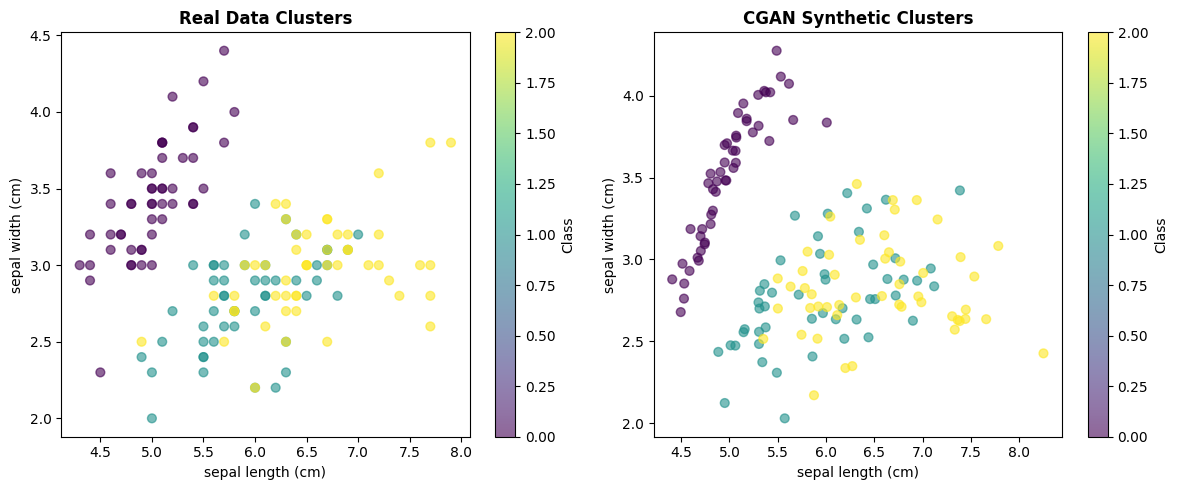

In [12]:
plt.figure(figsize=(12, 5))

# Real data scatter
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_real[:, 0], X_real[:, 1], c=y_real, cmap='viridis', alpha=0.6, s=40, label='Real Data')
plt.title('Real Data Clusters', fontsize=12, fontweight='bold')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.colorbar(scatter, label='Class')

# GAN data scatter
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_synthetic_gan[:, 0], X_synthetic_gan[:, 1], c=y_synthetic_gan, cmap='viridis', alpha=0.6, s=40, label='GAN Synthetic')
plt.title('CGAN Synthetic Clusters', fontsize=12, fontweight='bold')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.colorbar(scatter2, label='Class')

plt.tight_layout()
plt.show()

## PART 3: Synthetic Data Quality Evaluation

In [13]:
@dataclass
class SyntheticDataMetrics:
    method: str
    univariate_similarity: float
    correlation_similarity: float
    stat_distance: float
    downstream_utility: float

def compute_quality_metrics(X_real: np.ndarray, X_synthetic: np.ndarray,
                            y_real: np.ndarray, y_synthetic: np.ndarray,
                            method_name: str) -> SyntheticDataMetrics:
    """Compute synthetic data quality metrics."""
    
    # 1. Univariate similarity (KS test)
    ks_pvalues = []
    for col in range(X_real.shape[1]):
        ks_stat, p_val = ks_2samp(X_real[:, col], X_synthetic[:, col])
        ks_pvalues.append(p_val)
    univariate_sim = np.mean(ks_pvalues)
    
    # 2. Correlation structure similarity
    real_corr = np.corrcoef(X_real.T)
    synth_corr = np.corrcoef(X_synthetic.T)
    corr_diff = np.linalg.norm(real_corr - synth_corr, 'fro')
    correlation_sim = 1.0 / (1.0 + corr_diff)
    
    # 3. Statistical distance
    real_stats = np.concatenate([X_real.mean(axis=0), X_real.std(axis=0)])
    synth_stats = np.concatenate([X_synthetic.mean(axis=0), X_synthetic.std(axis=0)])
    stat_dist = np.linalg.norm(real_stats - synth_stats) / np.linalg.norm(real_stats)
    stat_distance = 1.0 - stat_dist
    
    # 4. Downstream utility (TSTR: Train Synthetic Test Real)
    knn_synth = KNeighborsClassifier(n_neighbors=3)
    knn_synth.fit(X_synthetic, y_synthetic)
    utility = knn_synth.score(X_real, y_real)
    
    return SyntheticDataMetrics(
        method=method_name,
        univariate_similarity=univariate_sim,
        correlation_similarity=correlation_sim,
        stat_distance=stat_distance,
        downstream_utility=utility
    )

In [ ]:
metrics_vae = compute_quality_metrics(X_real, X_synthetic_vae, y_real, y_synthetic_vae, 'VAE')
metrics_gan = compute_quality_metrics(X_real, X_synthetic_gan, y_real, y_synthetic_gan, 'GAN')

print(f'\nQuality Metrics Comparison:')
print(f'\nVAE:')
print(f'  Univariate Similarity (KS p): {metrics_vae.univariate_similarity:.4f}')
print(f'  Correlation Similarity: {metrics_vae.correlation_similarity:.4f}')
print(f'  Statistical Distance: {metrics_vae.stat_distance:.4f}')
print(f'  Downstream Utility: {metrics_vae.downstream_utility:.4f}')

print(f'\nGAN:')
print(f'  Univariate Similarity (KS p): {metrics_gan.univariate_similarity:.4f}')
print(f'  Correlation Similarity: {metrics_gan.correlation_similarity:.4f}')
print(f'  Statistical Distance: {metrics_gan.stat_distance:.4f}')
print(f'  Downstream Utility: {metrics_gan.downstream_utility:.4f}')


Computing quality metrics...

Quality Metrics Comparison:

VAE:
  Univariate Similarity (KS p): 0.0105
  Correlation Similarity: 0.4551
  Statistical Distance: 0.9690
  Downstream Utility: 0.9267

GAN:
  Univariate Similarity (KS p): 0.4453
  Correlation Similarity: 0.7097
  Statistical Distance: 0.9912
  Downstream Utility: 0.9800


### Visualizing Synthetic Data Quality Metrics

Let's visualize the quality metrics (univariate similarity, correlation similarity, statistical distance, downstream utility) for both VAE and GAN synthetic data using a bar plot.

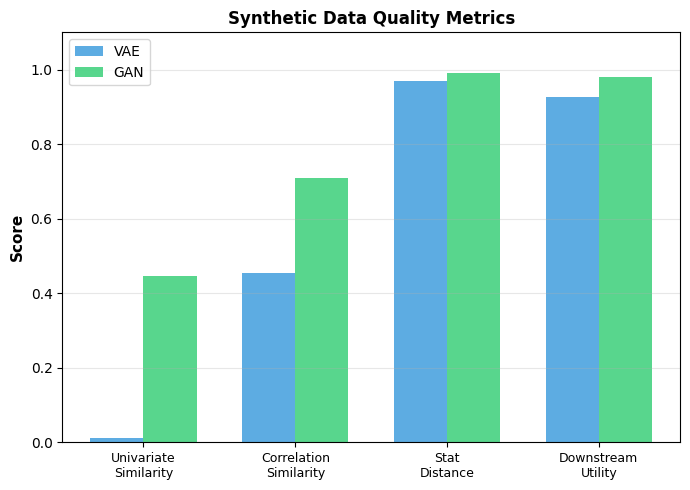

In [15]:
metrics_names = ['Univariate\nSimilarity', 'Correlation\nSimilarity', 'Stat\nDistance', 'Downstream\nUtility']
vae_vals = [metrics_vae.univariate_similarity, metrics_vae.correlation_similarity, metrics_vae.stat_distance, metrics_vae.downstream_utility]
gan_vals = [metrics_gan.univariate_similarity, metrics_gan.correlation_similarity, metrics_gan.stat_distance, metrics_gan.downstream_utility]

x_pos = np.arange(len(metrics_names))
width = 0.35
plt.figure(figsize=(7, 5))
plt.bar(x_pos - width/2, vae_vals, width, label='VAE', alpha=0.8, color='#3498db')
plt.bar(x_pos + width/2, gan_vals, width, label='GAN', alpha=0.8, color='#2ecc71')
plt.ylabel('Score', fontsize=11, fontweight='bold')
plt.title('Synthetic Data Quality Metrics', fontsize=12, fontweight='bold')
plt.xticks(x_pos, metrics_names, fontsize=9)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.ylim([0, 1.1])
plt.tight_layout()
plt.show()

## PART 4: Privacy Analysis - Membership Inference on Synthetic Data

In [16]:
def nearest_neighbor_distance(data_point: np.ndarray, dataset: np.ndarray) -> float:
    """Compute distance to nearest neighbor in dataset."""
    distances = np.linalg.norm(dataset - data_point, axis=1)
    return distances.min()

print("\nComputing membership inference resistance...")

# For each synthetic sample, find distance to nearest real sample
real_distances = []
for synth_sample in X_synthetic_vae:
    dist = nearest_neighbor_distance(synth_sample, X_real)
    real_distances.append(dist)

# For each real sample, find distance to nearest other real sample
real_self_distances = []
for real_sample in X_real:
    # Distance to nearest OTHER real sample
    distances = np.linalg.norm(X_real - real_sample, axis=1)
    distances[distances == 0] = np.inf  # Exclude self
    real_self_distances.append(distances.min())

real_distances = np.array(real_distances)
real_self_distances = np.array(real_self_distances)

print("\nMembership Inference Analysis:")
print(f"  Synthetic → Nearest Real: {real_distances.mean():.4f} ± {real_distances.std():.4f}")
print(f"  Real → Nearest Real: {real_self_distances.mean():.4f} ± {real_self_distances.std():.4f}")
print("\nInterpretation:")
if real_distances.mean() > real_self_distances.mean():
    print("  ✓ Synthetic samples are DISTINCT from training set")
    print("  ✓ Hard to infer membership of real samples")
else:
    print("  ✗ Synthetic samples are SIMILAR to training set")
    print("  ✗ May leak information about training set membership")


Computing membership inference resistance...

Membership Inference Analysis:
  Synthetic → Nearest Real: 0.1878 ± 0.0692
  Real → Nearest Real: 0.2506 ± 0.1191

Interpretation:
  ✗ Synthetic samples are SIMILAR to training set
  ✗ May leak information about training set membership


### Visualizing Membership Inference Resistance

Let's visualize the distribution of nearest neighbor distances for synthetic samples to real samples, and for real samples to other real samples. This helps us understand the privacy properties of the synthetic data.

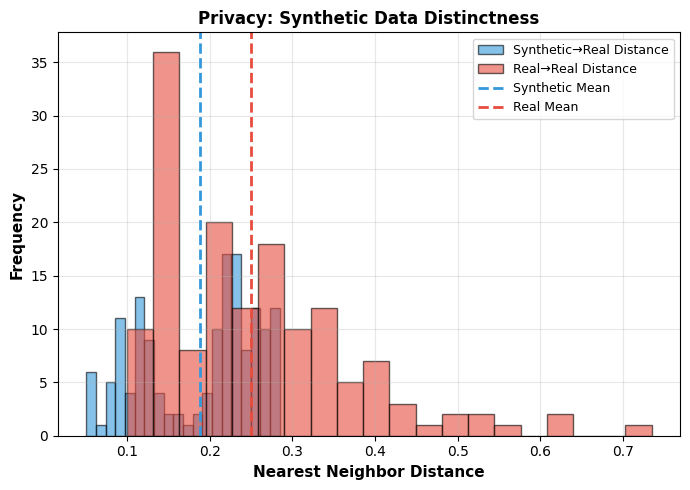

In [17]:
plt.figure(figsize=(7, 5))
plt.hist(real_distances, bins=20, alpha=0.6, label='Synthetic→Real Distance', color='#3498db', edgecolor='black')
plt.hist(real_self_distances, bins=20, alpha=0.6, label='Real→Real Distance', color='#e74c3c', edgecolor='black')
plt.axvline(real_distances.mean(), color='#3498db', linestyle='--', linewidth=2, label='Synthetic Mean')
plt.axvline(real_self_distances.mean(), color='#e74c3c', linestyle='--', linewidth=2, label='Real Mean')
plt.xlabel('Nearest Neighbor Distance', fontsize=11, fontweight='bold')
plt.ylabel('Frequency', fontsize=11, fontweight='bold')
plt.title('Privacy: Synthetic Data Distinctness', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### Exercise 1: Conditional Synthetic Data
Extend VAE/GAN to generate class-conditional synthetic data:
- Add class label as input to decoder/generator
- Generate synthetic samples for each Iris class separately
- Evaluate if class distributions are preserved

### Exercise 2: Differential Privacy Integration
Implement differentially private training:
- Add noise to gradients during VAE/GAN training
- Measure ε-δ privacy budget
- Compare privacy-utility trade-offs

### Exercise 3: Feature Importance via Synthetic
Use synthetic data to understand feature importance:
- Generate synthetic data with one feature removed/shuffled
- Measure ML model performance degradation
- Compare to SHAP/permutation importance

### Exercise 4: Adversarial Detection
Train adversarial detector to identify synthetic vs real:
- Train classifier on [real data, synthetic data] labels
- Measure AUC (detecting synthetic data)
- If AUC > 0.7, synthetic data quality is poor

### Exercise 5: Multi-Modal Data
Extend to mixed data types:
- Continuous features (using Normal distribution)
- Categorical features (using Categorical distribution)
- Implement on UCI Adult dataset

### Exercise 6: Anonymization Evaluation
Compare approaches for data release:
- Real data (baseline, not private)
- Synthetic data (fully private)
- k-Anonymized real data
- Differentially private real data

Which achieves best privacy-utility balance for ML?